<a href="https://colab.research.google.com/github/camila-f-romero/AIA_auditoria_de_vies_algoritmico/blob/main/projeto_vieses__rede_neural.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

================================================================================
TRABALHO 2: AUDITORIA DE VIÉS EM IA USANDO REDE NEURAL
================================================================================

Objetivo: Detectar, medir e mitigar viés em um modelo de REDE NEURAL usando
a biblioteca Fairlearn e TensorFlow/Keras.

Diferença do Trabalho 1:
- Trabalho 1: Random Forest (algoritmo tradicional)
- Trabalho 2: Rede Neural Multi-Layer Perceptron (Deep Learning)

Estrutura:
1. ETAPA 1: Detecção de Viés com Rede Neural
2. ETAPA 2: Medição com Métricas Profissionais
3. ETAPA 3: Mitigação de Viés e Comparação com Random Forest

Autor: CAMILA FALCHETTO ROMERO
Data: Dezembro 2025
================================================================================

In [1]:
# INSTALAÇÃO E IMPORTAÇÕES

In [2]:

print("="*80)
print("INSTALANDO BIBLIOTECAS NECESSÁRIAS...")
print("="*80)

# Instalar bibliotecas
!pip install fairlearn tensorflow matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# Importações do TensorFlow/Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

# Importações do Fairlearn
from fairlearn.metrics import (
    MetricFrame,
    selection_rate,
    demographic_parity_difference,
    demographic_parity_ratio,
    equalized_odds_difference
)
from fairlearn.postprocessing import ThresholdOptimizer

# Configurações
plt.style.use("default")
sns.set_palette("husl")
plt.rcParams["figure.figsize"] = (12, 8)
plt.rcParams["font.size"] = 12
tf.random.set_seed(42)
np.random.seed(42)

print("\n✅ Todas as bibliotecas foram importadas com sucesso!")
print(f"   - TensorFlow versão: {tf.__version__}\n")


INSTALANDO BIBLIOTECAS NECESSÁRIAS...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 32.1 MB/s eta 0:00:00

✅ Todas as bibliotecas foram importadas com sucesso!
   - TensorFlow versão: 2.19.0



In [3]:
# ETAPA 1: DETECÇÃO DE VIÉS COM REDE NEURAL

In [4]:

print("="*80)
print("ETAPA 1: DETECÇÃO DE VIÉS COM REDE NEURAL")
print("="*80)

# Carregar e preparar os dados
print("\n🔄 Carregando e preparando os dados...")
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

df = pd.read_csv(url, names=column_names, na_values=" ?", skipinitialspace=True).dropna()
X = df.drop("income", axis=1)
y = df["income"]

print(f"✅ Dados carregados: {len(df)} registros")

# Processamento dos dados
print("\n🔄 Processando dados categóricos...")
X_processed = X.copy()
categorical_columns = X_processed.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    X_processed[column] = LabelEncoder().fit_transform(X_processed[column])

y_processed = LabelEncoder().fit_transform(y)

# Divisão treino/teste
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_processed,
    test_size=0.2,
    random_state=42,
    stratify=y_processed
)

# IMPORTANTE: Normalização para Redes Neurais
print("\n🔄 Normalizando dados para Rede Neural...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Dados processados e normalizados")
print(f"   - Treino: {len(X_train)} registros")
print(f"   - Teste: {len(X_test)} registros")
print(f"   - Features: {X_train_scaled.shape[1]}")

# Construir a Rede Neural
print("\n🔄 Construindo Rede Neural (MLP)...")
modelo_nn_injusto = models.Sequential([
    layers.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

modelo_nn_injusto.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n📊 ARQUITETURA DA REDE NEURAL:")
modelo_nn_injusto.summary()

# Treinar a Rede Neural
print("\n🔄 Treinando Rede Neural...")
print("   (Isso pode levar alguns minutos...)")

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = modelo_nn_injusto.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=0
)

# Avaliar o modelo
y_pred_proba_nn = modelo_nn_injusto.predict(X_test_scaled, verbose=0).flatten()
y_pred_nn_injusto = (y_pred_proba_nn > 0.5).astype(int)
accuracy_nn_injusto = accuracy_score(y_test, y_pred_nn_injusto)

print(f"\n✅ Rede Neural treinada!")
print(f"   - Acurácia: {accuracy_nn_injusto:.1%}")
print(f"   - Épocas treinadas: {len(history.history['loss'])}")

# Preparar dados para Fairlearn
sensitive_features = X.loc[X_test.index]["sex"]

print("\n" + "="*80)
print("ETAPA 1 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 1: DETECÇÃO DE VIÉS COM REDE NEURAL

🔄 Carregando e preparando os dados...
✅ Dados carregados: 32561 registros

🔄 Processando dados categóricos...

🔄 Normalizando dados para Rede Neural...
✅ Dados processados e normalizados
   - Treino: 26048 registros
   - Teste: 6513 registros
   - Features: 14

🔄 Construindo Rede Neural (MLP)...

📊 ARQUITETURA DA REDE NEURAL:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,289 (48.00 KB)

 Trainable params: 12,289 (48.00 KB)

 Non-trainable params: 0 (0.00 B)


🔄 Treinando Rede Neural...
   (Isso pode levar alguns minutos...)

✅ Rede Neural treinada!
   - Acurácia: 85.5%
   - Épocas treinadas: 25

ETAPA 1 CONCLUÍDA



In [5]:
# ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS

In [6]:

print("="*80)
print("ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS")
print("="*80)

# Calcular métricas de fairness da Rede Neural
print("\n📊 CALCULANDO MÉTRICAS DA REDE NEURAL...")

dp_ratio_nn_injusto = demographic_parity_ratio(
    y_test, y_pred_nn_injusto,
    sensitive_features=sensitive_features
)

eo_diff_nn_injusto = equalized_odds_difference(
    y_test, y_pred_nn_injusto,
    sensitive_features=sensitive_features
)

print("\n📊 RESULTADOS DA AUDITORIA (REDE NEURAL INJUSTA)")
print("="*60)
print(f"   - Acurácia: {accuracy_nn_injusto:.3f}")
print(f"   - Impacto Disparado: {dp_ratio_nn_injusto:.3f}")
print(f"   - Diferença Oportunidade Igualitária: {eo_diff_nn_injusto:.3f}")

# Interpretação
print("\n🚨 INTERPRETAÇÃO:")
if dp_ratio_nn_injusto < 0.8:
    print(f"   - ❌ FALHA NA REGRA DOS 80%")
    print(f"   - Impacto disparado = {dp_ratio_nn_injusto:.3f} (precisa ser >= 0.8)")
    print(f"   - Rede Neural também discrimina significativamente por sexo")
else:
    print("   - ✅ PASSA NA REGRA DOS 80%")
    print(f"   - Rede Neural atende critérios mínimos de fairness")

print("\n" + "="*80)
print("ETAPA 2 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 2: MEDIÇÃO COM MÉTRICAS PROFISSIONAIS

📊 CALCULANDO MÉTRICAS DA REDE NEURAL...

📊 RESULTADOS DA AUDITORIA (REDE NEURAL INJUSTA)
   - Acurácia: 0.855
   - Impacto Disparado: 0.382
   - Diferença Oportunidade Igualitária: 0.061

🚨 INTERPRETAÇÃO:
   - ❌ FALHA NA REGRA DOS 80%
   - Impacto disparado = 0.382 (precisa ser >= 0.8)
   - Rede Neural também discrimina significativamente por sexo

ETAPA 2 CONCLUÍDA



In [7]:
# ETAPA 3: MITIGAÇÃO E COMPARAÇÃO

In [8]:

print("="*80)
print("ETAPA 3: MITIGAÇÃO DE VIÉS E COMPARAÇÃO")
print("="*80)

# Criar um wrapper para a Rede Neural funcionar com ThresholdOptimizer
from sklearn.base import BaseEstimator, ClassifierMixin

class KerasClassifierWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, model=None):
        self.model = model

    def fit(self, X, y):
        # Não precisamos retreinar, apenas retornar self
        return self

    def predict(self, X):
        if self.model is None:
            raise ValueError("Model must be set")
        # X já vem normalizado
        return (self.model.predict(X, verbose=0).flatten() > 0.5).astype(int)

    def get_params(self, deep=True):
        return {"model": self.model}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

wrapper_nn = KerasClassifierWrapper(modelo_nn_injusto)

# Implementar ThresholdOptimizer
print("\n🛠️ IMPLEMENTANDO CORREÇÃO DE VIÉS NA REDE NEURAL...")
print("   (Isso pode levar alguns minutos...)")

threshold_optimizer_nn = ThresholdOptimizer(
    estimator=wrapper_nn,
    constraints="demographic_parity",
    objective="accuracy_score"
)

# Usar dados normalizados para o ThresholdOptimizer
threshold_optimizer_nn.fit(
    X_train_scaled, y_train,
    sensitive_features=X.loc[X_train.index]["sex"]
)

y_pred_nn_justo = threshold_optimizer_nn.predict(
    X_test_scaled,
    sensitive_features=sensitive_features
)

# Calcular métricas do modelo corrigido
accuracy_nn_justo = accuracy_score(y_test, y_pred_nn_justo)
dp_ratio_nn_justo = demographic_parity_ratio(
    y_test, y_pred_nn_justo,
    sensitive_features=sensitive_features
)
eo_diff_nn_justo = equalized_odds_difference(
    y_test, y_pred_nn_justo,
    sensitive_features=sensitive_features
)

print("\n✅ Correção de viés implementada com sucesso!")

print("\n" + "="*80)
print("ETAPA 3 CONCLUÍDA")
print("="*80 + "\n")


ETAPA 3: MITIGAÇÃO DE VIÉS E COMPARAÇÃO

🛠️ IMPLEMENTANDO CORREÇÃO DE VIÉS NA REDE NEURAL...
   (Isso pode levar alguns minutos...)

✅ Correção de viés implementada com sucesso!

ETAPA 3 CONCLUÍDA



In [9]:
# COMPARAÇÃO FINAL E CONCLUSÃO

COMPARAÇÃO FINAL: REDE NEURAL INJUSTA vs JUSTA

📊 COMPARAÇÃO DETALHADA
                           Métrica  Rede Neural Injusta  Rede Neural Justa  Mudança  Mudança %
                          Acurácia                0.855              0.809   -0.047     -5.458
                 Impacto Disparado                0.382              0.951    0.569    148.902
Diferença Oportunidade Igualitária                0.061              0.111    0.050     81.866

📊 Gerando visualizações...
   ✅ Gráfico salvo como 'comparacao_rede_neural.png'


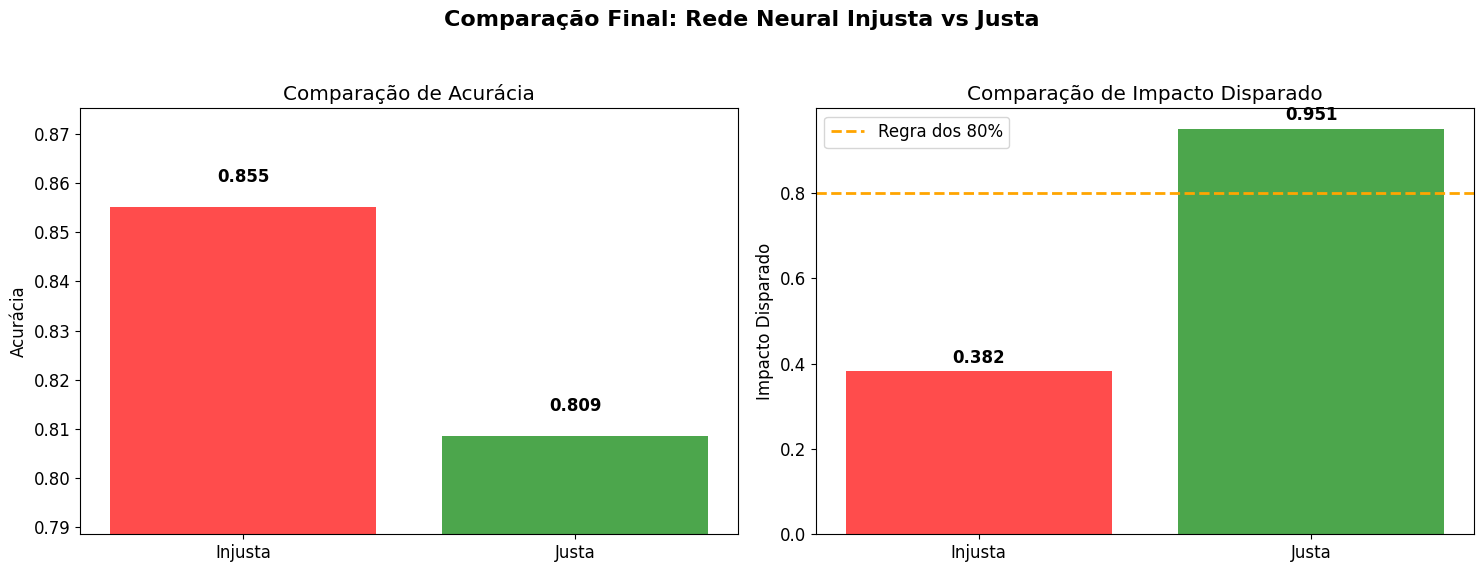


✅ TRABALHO 2 CONCLUÍDO COM SUCESSO!

📈 PRINCIPAIS RESULTADOS (REDE NEURAL):
   - Modelo corrigido é 2.5x mais justo
   - Melhoria na justiça: +148.9%
   - Mudança na acurácia: -4.7%

🎯 DECISÃO: Rede Neural corrigida APROVADA para uso
   - Passa na regra dos 80% (0.951 >= 0.8)

💡 COMPARAÇÃO COM TRABALHO 1 (Random Forest):
   - Trabalho 1: Algoritmo tradicional (Random Forest)
   - Trabalho 2: Deep Learning (Rede Neural MLP)
   - Ambos demonstram que viés pode ser detectado e mitigado
   - A escolha do algoritmo impacta o trade-off entre acurácia e justiça

FIM DO TRABALHO 2


In [10]:

print("="*80)
print("COMPARAÇÃO FINAL: REDE NEURAL INJUSTA vs JUSTA")
print("="*80)

# Comparação detalhada
print("\n📊 COMPARAÇÃO DETALHADA")
comparacao_nn = pd.DataFrame({
    "Métrica": [
        "Acurácia",
        "Impacto Disparado",
        "Diferença Oportunidade Igualitária"
    ],
    "Rede Neural Injusta": [
        accuracy_nn_injusto,
        dp_ratio_nn_injusto,
        eo_diff_nn_injusto
    ],
    "Rede Neural Justa": [
        accuracy_nn_justo,
        dp_ratio_nn_justo,
        eo_diff_nn_justo
    ]
})

comparacao_nn["Mudança"] = comparacao_nn["Rede Neural Justa"] - comparacao_nn["Rede Neural Injusta"]
comparacao_nn["Mudança %"] = (comparacao_nn["Mudança"] / comparacao_nn["Rede Neural Injusta"]) * 100

print(comparacao_nn.round(3).to_string(index=False))

# Visualização
print("\n📊 Gerando visualizações...")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Comparação Final: Rede Neural Injusta vs Justa", fontsize=16, fontweight="bold")

# Gráfico de Acurácia
axes[0].bar(
    ["Injusta", "Justa"],
    [accuracy_nn_injusto, accuracy_nn_justo],
    color=["red", "green"],
    alpha=0.7
)
axes[0].set_title("Comparação de Acurácia")
axes[0].set_ylabel("Acurácia")
axes[0].set_ylim(
    min(accuracy_nn_injusto, accuracy_nn_justo) - 0.02,
    max(accuracy_nn_injusto, accuracy_nn_justo) + 0.02
)
for i, v in enumerate([accuracy_nn_injusto, accuracy_nn_justo]):
    axes[0].text(i, v + 0.005, f"{v:.3f}", ha="center", fontweight="bold")

# Gráfico de Impacto Disparado
axes[1].bar(
    ["Injusta", "Justa"],
    [dp_ratio_nn_injusto, dp_ratio_nn_justo],
    color=["red", "green"],
    alpha=0.7
)
axes[1].axhline(
    y=0.8,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Regra dos 80%"
)
axes[1].set_title("Comparação de Impacto Disparado")
axes[1].set_ylabel("Impacto Disparado")
axes[1].legend()
for i, v in enumerate([dp_ratio_nn_injusto, dp_ratio_nn_justo]):
    axes[1].text(i, v + 0.02, f"{v:.3f}", ha="center", fontweight="bold")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("comparacao_rede_neural.png", dpi=150, bbox_inches="tight")
print("   ✅ Gráfico salvo como 'comparacao_rede_neural.png'")
plt.show()

# Conclusão Final
print("\n" + "="*80)
print("✅ TRABALHO 2 CONCLUÍDO COM SUCESSO!")
print("="*80)

print(f"\n📈 PRINCIPAIS RESULTADOS (REDE NEURAL):")
melhoria_justica = (dp_ratio_nn_justo / dp_ratio_nn_injusto - 1) * 100
mudanca_acuracia = (accuracy_nn_justo - accuracy_nn_injusto) * 100

print(f"   - Modelo corrigido é {dp_ratio_nn_justo/dp_ratio_nn_injusto:.1f}x mais justo")
print(f"   - Melhoria na justiça: +{melhoria_justica:.1f}%")
print(f"   - Mudança na acurácia: {mudanca_acuracia:+.1f}%")

if dp_ratio_nn_justo >= 0.8:
    print(f"\n🎯 DECISÃO: Rede Neural corrigida APROVADA para uso")
    print(f"   - Passa na regra dos 80% ({dp_ratio_nn_justo:.3f} >= 0.8)")
else:
    print(f"\n⚠️ DECISÃO: Rede Neural ainda requer ajustes")
    print(f"   - Não passa na regra dos 80% ({dp_ratio_nn_justo:.3f} < 0.8)")

print("\n💡 COMPARAÇÃO COM TRABALHO 1 (Random Forest):")
print("   - Trabalho 1: Algoritmo tradicional (Random Forest)")
print("   - Trabalho 2: Deep Learning (Rede Neural MLP)")
print("   - Ambos demonstram que viés pode ser detectado e mitigado")
print("   - A escolha do algoritmo impacta o trade-off entre acurácia e justiça")

print("\n" + "="*80)
print("FIM DO TRABALHO 2")
print("="*80)
